# 이상징후 탐지
이상징후 경보 - 이상해요 조치 취해주세요
이상징후 탐지 - 이상한 것 같은데 알려줘야징
이상탐지 - 이상이 발생

평소와 다르다를 판단하기 위해서는 평소가 무엇인지를 정해야 하고 얼마나 달라야 이상한 것인지를 판단할 기준이 필요하다. 평소와 다른 징후를 찾는 행위를 이상징후 탐지anomaly detection고 일컫는다.

어떤 상황이 이상한 상황인지 어떤 흐름이 이상하게 가고 있는 흐름인지 알 수 있어야 한다.

## 이상징후란
이상치outlier는 다른 값들과 동떨어진 값을 가르키는 통계용어이다. 이상징후는 이상치보다 한단계 더 아나가 평소의 패턴에서 벗어나서 확인이 필요한 신호로 볼 수 있다.

### 이상징후의 모양
- 점 이상point anomaly: 값 하나가 전체에서 동떨어진 경우
- 맥락 이상contextual anomaly:값 자체는 이상이 없는데 그 상황에서는 동떨어진 경우
- 집단 이상 collective anomaly: 값 하나는 평범하지만 여러 개가 모인 모양이 동떨어진 경우 - 항구 성장추세 전쟁,소요,파업 등으로 떨어졌는데 뭔가 예년과 달라 근데 값은 괜찮아..
-
이 세가지 모양의 이상징후를 탐지하는 방법과 기준이 다르기 때문에 모양을 구분하는 것이 바람직하다. 점 이상은 전체 분포를 찾는 것이 가능하지만 맥락이상과 같은 경우에는 같은 맥락(요일,선종,계절)끼리 비교해야 찾을 수 있고 집단 이상은 여러 시점을 묶어야 확인할 수 있기 때문이다.

## 도표에서 이상징후를 찾기
데이터를 분석하기 위해서는 도표를 그리는 것이 가장 확실한 빙법이다. 도표에서 어떤 모양의 이상이 있는가 평소의 흔들림은 어느 정도인가. 기준을 어디에 두어야 하는가 같은 내용을 확인하기 쉽기 때문이다.

- 선그래프+기준 밴드: 시간에 따른 값과 평소 범위를 나타내고 점 이상, 집단 이상
- 상자 수염 그래프: 그룹마다 평소 범위와 밖의 점을 나타내고 맥락이상
- 산점도: 두 변수의 조합, 조합 이상

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def load_dataset(filename):
    BASE_DIR = './data'
    EXTENSION = '.csv'
    TARGET_PATH = f'{BASE_DIR}/{filename}{EXTENSION}'
    try:
        return pd.read_csv(TARGET_PATH)
    except FileNotFoundError:
        return None
    except UnicodeDecodeError:
        return pd.read_csv(TARGET_PATH, encoding='euc-kr')

In [10]:
weekly_shape = np.array([122,125,129,130,132,126,108])
base = np.tile(weekly_shape, 4).astype(float)
len(base)






28

In [11]:
base

array([122., 125., 129., 130., 132., 126., 108., 122., 125., 129., 130.,
       132., 126., 108., 122., 125., 129., 130., 132., 126., 108., 122.,
       125., 129., 130., 132., 126., 108.])

In [13]:
weekly_shape = np.array([122,125,129,130,132,126,108])
base = np.tile(weekly_shape, 4).astype(float)
days = pd.date_range('2026-03-02', periods=28)


In [14]:
point = base.copy()
point[10]=35 # 점이상
context = base.copy()
context[17]=108 # 맥락이상
collective = base.copy()
collective[[15,16,17]]=[112,104,96] # 집단이상

In [16]:
series = pd.Series(point, index=days)

series

2026-03-02    122.0
2026-03-03    125.0
2026-03-04    129.0
2026-03-05    130.0
2026-03-06    132.0
2026-03-07    126.0
2026-03-08    108.0
2026-03-09    122.0
2026-03-10    125.0
2026-03-11    129.0
2026-03-12     35.0
2026-03-13    132.0
2026-03-14    126.0
2026-03-15    108.0
2026-03-16    122.0
2026-03-17    125.0
2026-03-18    129.0
2026-03-19    130.0
2026-03-20    132.0
2026-03-21    126.0
2026-03-22    108.0
2026-03-23    122.0
2026-03-24    125.0
2026-03-25    129.0
2026-03-26    130.0
2026-03-27    132.0
2026-03-28    126.0
2026-03-29    108.0
Freq: D, dtype: float64

시계열 데이터의 이상anomaly을 보는 기본적인 도표는 기준선baseline과 기준 밴드band를 겹쳐서 그리는 방법이다.

기준선은 평소라면 이 정도라는 값 밴드 평소의 흔들림은 이 범위 안이라는 폭을 의미한다.

밴드 밖으로 나간 점이 있다면 이상 징후가 된다. 기준선으로 전체 평균을 사용하면 계산은 쉬워질 수 있지만 값이 서서히 변하는 시계열에서는 기준이 뒤쳐진다. 최근 며칠의 이동 중앙값을 기준선으로 사용한다.

이상값 자체가 기준선을 끌고 다니기 때문에  우리의 데이터에서는 평균은 하루에 35척으로 끌려 가지만 중앙값은 거의 안 움직인다. 이러한 성질을 강건함이라고 일컫는다.

In [18]:
baseline = series.rolling(7, center=True, min_periods=4).median()
mean_line = series.rolling(7, center=True, min_periods=4).mean()

upper, lower = baseline * 1.2 , baseline * 0.8

In [19]:
print(mean_line.iloc[10], baseline.iloc[10])

111.0 125.0


In [20]:
outside = series[(series> upper) | (series< lower)] # 이상치

C:\Users\user\AppData\Local\Temp\ipykernel_1900\327871293.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


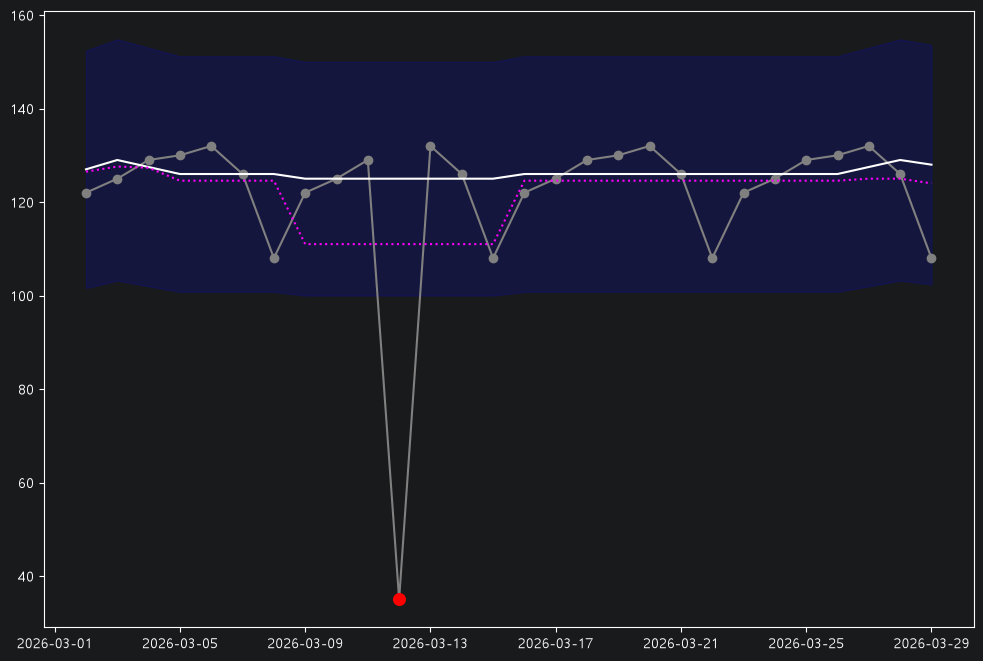

In [22]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(series.index, series, color= 'gray', marker='o', label='입항 척수')
ax.plot(baseline.index, baseline, color='white',label='기준선(7일 이동 중앙값)')
ax.plot(mean_line.index, mean_line, color='magenta', linestyle= ':', label='기준밴드')
ax.fill_between(series.index, lower, upper, color='blue', alpha=0.15,label='기준밴드')

ax.scatter(outside.index, outside, color='red', s=70, zorder=3, label='밴드 밖의 점') # 이상한 놈이 어디에 있는지 확인 가능

fig.show()

